# 02 - Generalizability

## Imports

In [69]:
import numpy as np
import matplotlib.pyplot as plt
# Make sure we get outputs from a probabilitistic model each time (for reproducibility) 
np.random.seed(1515)

## Prediction with Good vs. Bad Data

Let's go back to our previous example with the test scores. Suppose we are now interested in using the Period 3 relationship between studying and test scores to understand the relationship for the other AP Calc class, Period 1. 

Now, imagine that we have two different scenarios, one where we saw the good data, and one where we saw the bad data. We only see one of the datasets, so we are going to build our models off of the two different datasets. 

### Model for Good Data

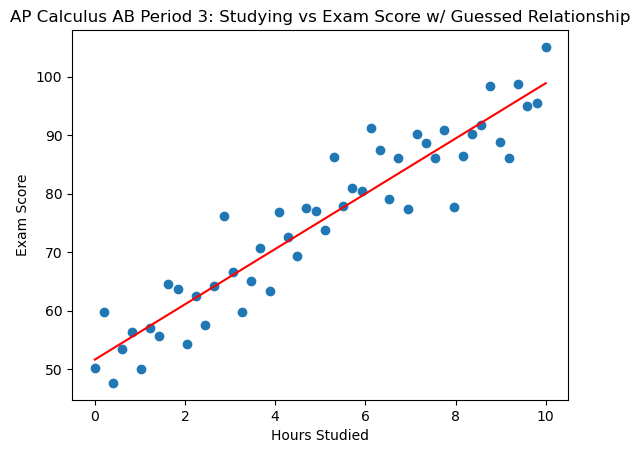

In [74]:
# copy and pasting code over from other notebook

# Hours studied
hours = np.linspace(0, 10, 50)

# Exam score with moderate noise
scores_good = 5 * hours + 50 + np.random.normal(0, 5, size=len(hours))

slope_good, intercept_good = np.polyfit(hours, scores_good, deg=1) # fit a polynomial to your data 
y_fit_good = slope_good * hours + intercept_good

plt.figure()
plt.scatter(hours, scores_good)
plt.plot(hours, y_fit_good, color = 'red')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("AP Calculus AB Period 3: Studying vs Exam Score w/ Guessed Relationship")
plt.show()

Our guess for a line seems like it models the data pretty well! We will get to using math to show that it does do a good job of fitting, but for now we can just use our visual to see that it does a good job on the data. So, let's save the values here for our good model:

In [77]:
good_model = [slope_good, intercept_good]

### Model for Bad Data

Let's look at the line we picked last time for our bad data: 

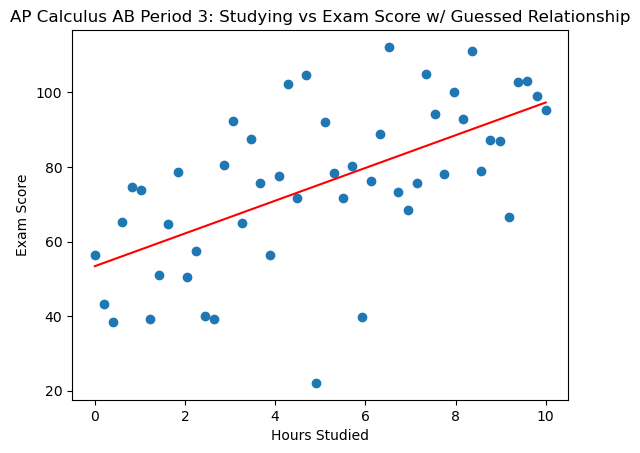

In [87]:
scores_bad = 5 * hours + 50 + np.random.normal(0, 20, size=len(hours))

slope_bad, intercept_bad = np.polyfit(hours, scores_bad, deg=1) # fit a polynomial to your data 
y_fit_bad = slope_bad * hours + intercept_bad

plt.figure()
plt.scatter(hours, scores_bad)
plt.plot(hours, y_fit_bad, color = 'red')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("AP Calculus AB Period 3: Studying vs Exam Score w/ Guessed Relationship")
plt.show()

As we talked about before, this line doesn't visually look like it is a good fit for our data! While we do know that this data is noisy, in real life, we wouldn't have this information. So, we have to make a good guess as to what the relationship in this data looks like. Let's see if this type of relationship looks a little more accurate: 

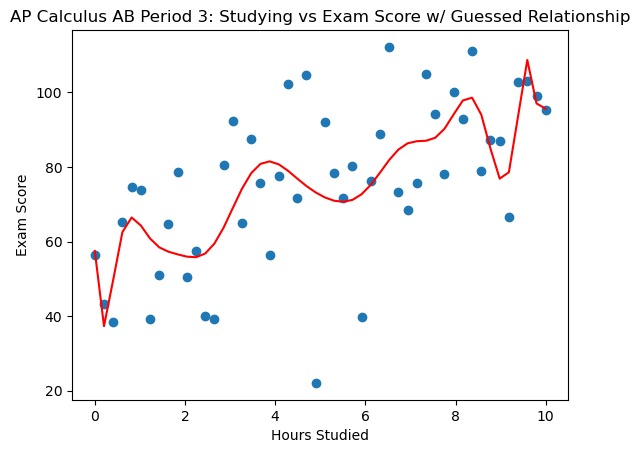

In [90]:
coeffs_bad = np.polyfit(hours, scores_bad, deg=17) # fit a polynomial to your data 
bad_poly = np.poly1d(coeffs_bad) # create a function that uses this polynomial
y_fit_bad = bad_poly(hours)

plt.figure()
plt.scatter(hours, scores_bad)
plt.plot(hours, y_fit_bad, color = 'red')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("AP Calculus AB Period 3: Studying vs Exam Score w/ Guessed Relationship")
plt.show()

Ok, this looks like it is fitting our data a little bit better. More of the dots are connected, but still it is by no means perfect. 

Now that we have our models, how do we know that the "bad" one is actually worse? 

### Model Performance Comparison